# Feature Embeddings Visualization

This notebook visualizes learned feature embeddings using dimensionality reduction techniques (t‑SNE, UMAP). It helps understand how the model separates benign and malignant samples in the latent space.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import umap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (10, 8)

## Load Model and Data

First, load a trained model and the test dataset. You need to specify the path to a checkpoint and the config file used for training.

In [2]:
import sys
from pathlib import Path
sys.path.append('..')
from src.data.dataset import CBISDDSMDataset
from src.models.efficientnet import EfficientNetClassifier
from src.data.transforms import get_transforms
from src.training import get_device
import yaml

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'configs').exists() and (candidate / 'src').exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate project root from the current notebook kernel.')

PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results_v2'
DEFAULT_EXPERIMENT = RESULTS_DIR / 'supervised_500'

if not DEFAULT_EXPERIMENT.exists():
    raise FileNotFoundError(f'Default experiment not found: {DEFAULT_EXPERIMENT}')

config_path = DEFAULT_EXPERIMENT / 'config.yaml'
checkpoint_path = DEFAULT_EXPERIMENT / 'best_model.pth'

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

image_size = config['dataset']['image_size']
test_transform = get_transforms('test', image_size=image_size)

test_dataset = CBISDDSMDataset(
    data_dir=str(PROJECT_ROOT / 'data'),
    abnormality_type=config['dataset']['abnormality_type'],
    split='test',
    transform=test_transform,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
)

model = EfficientNetClassifier(
    num_classes=config['model']['num_classes'],
    pretrained=False,
    dropout_rate=config['model'].get('dropout_rate', 0.2),
    freeze_backbone=config['model'].get('freeze_backbone', False),
)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded model from {checkpoint_path}')
print(f'Test dataset size: {len(test_dataset)}')


Loaded model from /Users/grmim/Dev/ssl/results_v2/supervised_500/best_model.pth
Test dataset size: 361


## Extract Embeddings

Forward pass through the model to obtain feature vectors (before the classification head).

In [3]:
def extract_embeddings(model, dataloader, device='cpu'):
    """Extract embeddings and labels from a model."""
    model.to(device)
    embeddings = []
    labels = []
    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            # Get features before classification head
            feats = model.get_features(images)  # shape: (batch, 1280)
            embeddings.append(feats.cpu().numpy())
            labels.append(targets.numpy())
    return np.vstack(embeddings), np.concatenate(labels)

device = get_device()
embeddings, labels = extract_embeddings(model, test_loader, device)
print(f'Embeddings shape: {embeddings.shape}')
print(f'Labels shape: {labels.shape}')

Embeddings shape: (361, 1280)
Labels shape: (361,)


## t‑SNE Visualization

Reduce dimensionality to 2D using t‑SNE and color points by ground‑truth label.

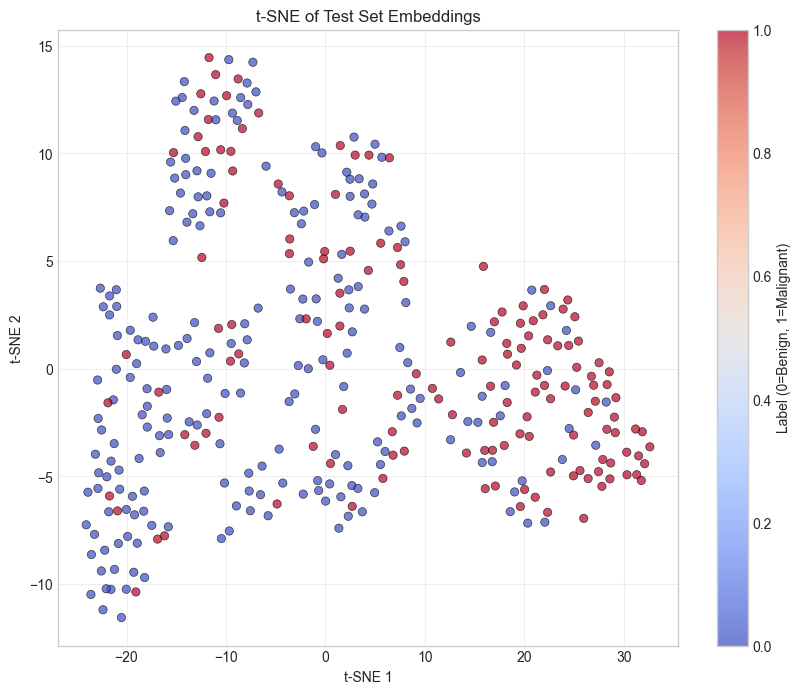

In [4]:
tsne_perplexity = min(30, max(5, len(embeddings) // 10))
tsne = TSNE(n_components=2, random_state=42, perplexity=tsne_perplexity)
embeddings_tsne = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_tsne[:, 0],
    embeddings_tsne[:, 1],
    c=labels,
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5,
)
plt.colorbar(scatter, label='Label (0=Benign, 1=Malignant)')
plt.title('t-SNE of Test Set Embeddings')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.show()


## UMAP Visualization

Alternative dimensionality reduction using UMAP (often preserves local structure better).

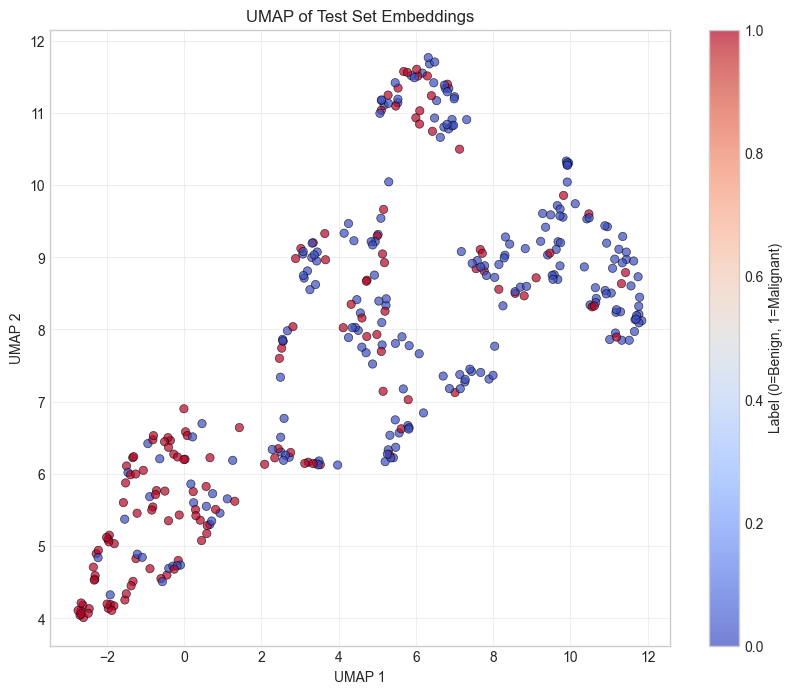

In [5]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_umap = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_umap[:, 0],
    embeddings_umap[:, 1],
    c=labels,
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='k',
    linewidth=0.5
)
plt.colorbar(scatter, label='Label (0=Benign, 1=Malignant)')
plt.title('UMAP of Test Set Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.3)
plt.show()

## Per‑Class Density

Kernel density estimation (KDE) plots for each class along the first two principal components.

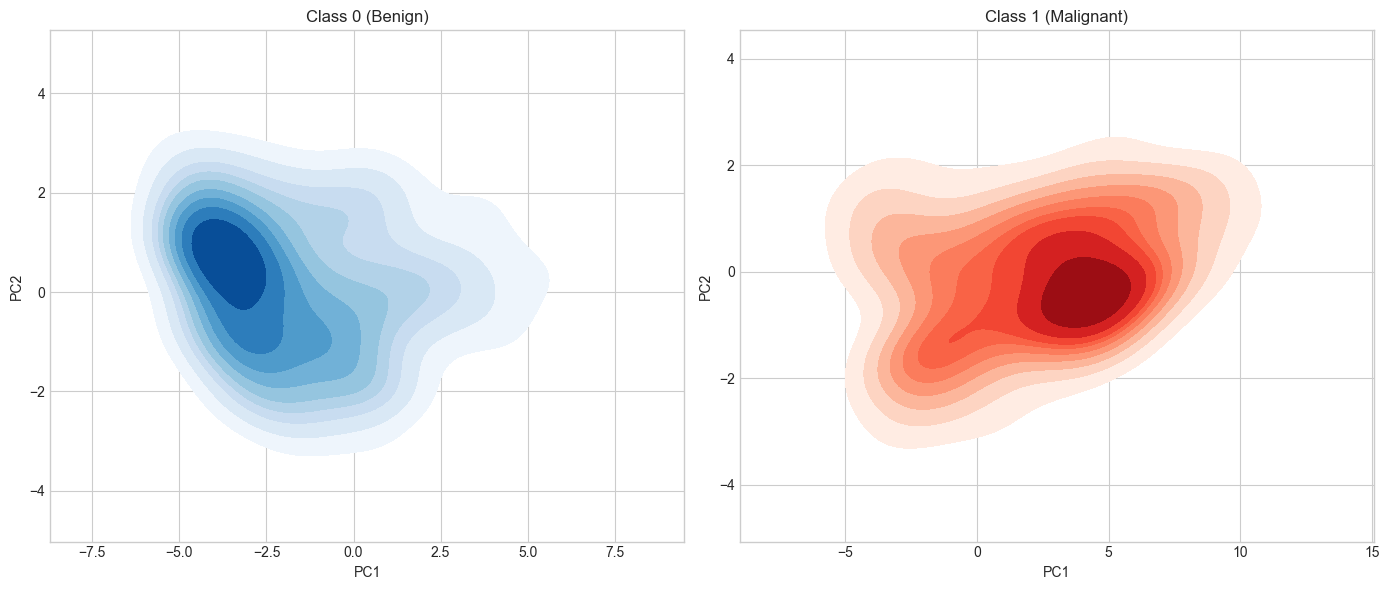

In [6]:
from sklearn.decomposition import PCA

# Reduce to 2D with PCA for KDE
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for idx, class_label in enumerate([0, 1]):
    mask = labels == class_label
    sns.kdeplot(
        x=embeddings_pca[mask, 0],
        y=embeddings_pca[mask, 1],
        ax=axes[idx],
        fill=True,
        cmap='Blues' if class_label == 0 else 'Reds',
        thresh=0.1
    )
    axes[idx].set_title(f'Class {class_label} ({"Benign" if class_label == 0 else "Malignant"})')
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
plt.tight_layout()
plt.show()

## Comparing Supervised vs SSL Embeddings

(Optional) Load embeddings from multiple trained models and compare separability.

In [7]:
# Multi-model embedding comparison
import random
from pathlib import Path
from sklearn.metrics import silhouette_score
from torch.utils.data import Subset


def load_model_from_experiment(exp_dir):
    exp_dir = Path(exp_dir)
    config_path = exp_dir / 'config.yaml'
    checkpoint_path = exp_dir / 'best_model.pth'

    if not config_path.exists() or not checkpoint_path.exists():
        raise FileNotFoundError(f'Missing config or checkpoint in {exp_dir}')

    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    model_config = config.get('model', {})
    model = EfficientNetClassifier(
        num_classes=model_config.get('num_classes', 2),
        pretrained=False,
        dropout_rate=model_config.get('dropout_rate', 0.2),
        freeze_backbone=model_config.get('freeze_backbone', False),
    )

    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f'Loaded model from {exp_dir.name}')
    return model, config


def get_test_dataloader(config, batch_size=32, max_samples=None, seed=42):
    dataset_config = config.get('dataset', {})
    test_transform = get_transforms('test', image_size=dataset_config.get('image_size', 512))

    test_dataset = CBISDDSMDataset(
        split='test',
        abnormality_type=dataset_config.get('abnormality_type', 'mass'),
        labeled_subset_size=None,
        transform=test_transform,
        data_dir=str(PROJECT_ROOT / 'data'),
    )

    if max_samples is not None and max_samples < len(test_dataset):
        rng = random.Random(seed)
        indices = list(range(len(test_dataset)))
        rng.shuffle(indices)
        indices = indices[:max_samples]
        test_dataset = Subset(test_dataset, indices)
        print(f'Using subset of {max_samples} samples (seed={seed})')

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=min(4, config.get('training', {}).get('num_workers', 4)),
        pin_memory=torch.cuda.is_available(),
    )

    print(f'Test dataset: {len(test_dataset)} samples')
    return test_loader


def compute_separability_metrics(embeddings, labels, normalize=True):
    metrics = {}
    if normalize:
        eps = 1e-8
        emb_mean = embeddings.mean(axis=0, keepdims=True)
        emb_std = embeddings.std(axis=0, keepdims=True) + eps
        embeddings = (embeddings - emb_mean) / emb_std

    if len(np.unique(labels)) > 1:
        metrics['silhouette'] = silhouette_score(embeddings, labels)

    class_0_mask = labels == 0
    class_1_mask = labels == 1
    if np.any(class_0_mask) and np.any(class_1_mask):
        centroid_0 = embeddings[class_0_mask].mean(axis=0)
        centroid_1 = embeddings[class_1_mask].mean(axis=0)
        centroid_dist = np.linalg.norm(centroid_0 - centroid_1)
        metrics['centroid_distance'] = centroid_dist
        var_within_0 = embeddings[class_0_mask].var(axis=0).mean()
        var_within_1 = embeddings[class_1_mask].var(axis=0).mean()
        metrics['separation_ratio'] = centroid_dist**2 / (var_within_0 + var_within_1 + 1e-8)
    return metrics


def discover_experiments(results_dir):
    results_dir = Path(results_dir)
    if not results_dir.exists():
        return []
    experiments = []
    for exp_dir in results_dir.iterdir():
        if exp_dir.is_dir() and (exp_dir / 'config.yaml').exists() and (exp_dir / 'best_model.pth').exists():
            experiments.append(exp_dir)
    experiments.sort(key=lambda p: p.name)
    print(f'Found {len(experiments)} experiments: {[e.name for e in experiments]}')
    return experiments


def compare_embeddings(results_dir=RESULTS_DIR, models=None, batch_size=32,
                       device='cuda' if torch.cuda.is_available() else 'cpu',
                       max_samples=None, seed=42):
    experiments = [Path(results_dir) / m for m in models] if models else discover_experiments(results_dir)
    if not experiments:
        raise ValueError(f'No valid experiments found in {results_dir}')

    all_metrics = []
    embeddings_data = {}

    for exp_dir in experiments:
        print(f'Processing {exp_dir.name}...')
        model, config = load_model_from_experiment(exp_dir)
        test_loader = get_test_dataloader(config, batch_size=batch_size, max_samples=max_samples, seed=seed)
        embeddings, labels = extract_embeddings(model, test_loader, device=device)
        embeddings_data[exp_dir.name] = {'embeddings': embeddings, 'labels': labels, 'config': config}
        metrics = compute_separability_metrics(embeddings, labels)
        metrics['experiment'] = exp_dir.name
        metrics['model_type'] = config.get('ssl', {}).get('method', 'supervised')
        metrics['labeled_subset'] = config.get('dataset', {}).get('labeled_subset_size') or 'full'
        all_metrics.append(metrics)

    df = pd.DataFrame(all_metrics).sort_values('experiment')
    return df, embeddings_data

# Example: compare two experiments quickly
compare_df, compare_embeddings_data = compare_embeddings(models=['supervised_100', 'fixmatch_100'], max_samples=100)
compare_df


Processing supervised_100...
Loaded model from supervised_100
Using subset of 100 samples (seed=42)
Test dataset: 100 samples
Processing fixmatch_100...
Loaded model from fixmatch_100
Using subset of 100 samples (seed=42)
Test dataset: 100 samples


,silhouette,centroid_distance,separation_ratio,experiment,model_type,labeled_subset
1,0.013613,9.523633,45.702156,fixmatch_100,fixmatch,100
0,0.010391,9.448559,45.645000,supervised_100,fixmatch,100


## Summary

This notebook provides tools to visualize and analyze learned feature embeddings. Key insights:
- Well‑separated embeddings indicate good representation learning.
- Overlap suggests confusion between classes.
- SSL embeddings may show better structure when labeled data is scarce.